In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def linear_least_squares(x, y):
    """
    Manually calculates the linear best-fit parameters and their uncertainties.
    """
    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    # Calculate sum of squares
    s_xx = np.sum((x - x_mean)**2)
    s_xy = np.sum((x - x_mean) * (y - y_mean))
    
    # Gradient (m) and Intercept (c)
    m = s_xy / s_xx
    c = y_mean - m * x_mean
    
    # Calculate residuals and uncertainty in data points (dy)
    y_pred = m * x + c
    residuals = y - y_pred
    
    # Standard deviation of the residuals (Estimated uncertainty in data points)
    # n-2 degrees of freedom for a linear fit
    dy = np.sqrt(np.sum(residuals**2) / (n - 2))
    
    # Uncertainty in m and c (Standard Errors)
    dm = dy / np.sqrt(s_xx)
    dc = dy * np.sqrt((1/n) + (x_mean**2 / s_xx))
    
    return m, c, dm, dc, dy

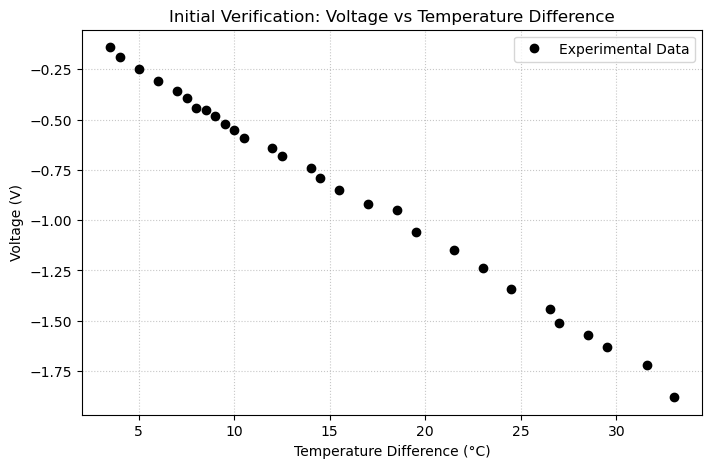

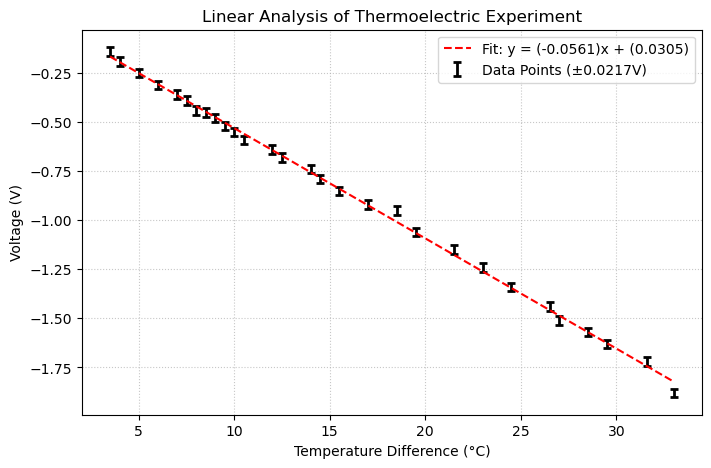

--- Fit Results ---
Gradient (m):          -0.056146 ± 0.000456 V/°C
y-intercept (c):       0.030487 ± 0.008243 V
Uncertainty in points: 0.021686 V


In [25]:
# 1. Load the data
df = pd.read_csv('thermoelectric_exp1_data.csv')
x = df['Difference /C'].values
y = df['Voltage /V'].values

# 2. Simple plot of raw data for visual verification
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'ko', label='Experimental Data')
plt.xlabel('Temperature Difference (°C)')
plt.ylabel('Voltage (V)')
plt.title('Initial Verification: Voltage vs Temperature Difference')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

# 3. Perform the  linear fit
m, c, dm, dc, dy = linear_least_squares(x, y)

# 4. Final plot with error bars and the best-fit line
plt.figure(figsize=(8, 5))

# Plot data points as error bars using calculated dy
plt.errorbar(x, y, yerr=dy,color='black',
             capsize=3, elinewidth=2, markeredgewidth=2, linestyle='', label=f'Data Points (±{dy:.4f}V)')

# Plot the dashed fit line
x_fit = np.linspace(min(x), max(x), 100)
y_fit = m * x_fit + c
plt.plot(x_fit, y_fit, 'r--', label=f'Fit: y = ({m:.4f})x + ({c:.4f})')

plt.xlabel('Temperature Difference (°C)')
plt.ylabel('Voltage (V)')
plt.title('Linear Analysis of Thermoelectric Experiment')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

# 5. Print results
print(f"--- Fit Results ---")
print(f"Gradient (m):          {m:.6f} ± {dm:.6f} V/°C")
print(f"y-intercept (c):       {c:.6f} ± {dc:.6f} V")
print(f"Uncertainty in points: {dy:.6f} V")